# Лабораторная работа №1
## Разведочный анализ данных. Исследование и визуализация данных.

**Цель лабораторной работы:** изучение различных методов визуализация данных.

**Краткое описание:** Построение основных графиков, входящих в этап разведочного анализа данных.

### Требования к отчету:

**Отчет по лабораторной работе должен содержать:**
- титульный лист;
- описание задания;
- текст программы;
- экранные формы с примерами выполнения программы.

В случае использования ноутбуков фрагменты 3 и 4 соответствуют ячейкам ноутбуков. Отчеты размещаются в репозитории курса, который каждый студент создает в своем профиле на github.

### Задание:

- Выбрать набор данных (датасет). Вы можете найти список свободно распространяемых датасетов здесь.
- Для первой лабораторной работы рекомендуется использовать датасет без пропусков в данных, например из Scikit-learn.
- Пример преобразования датасетов Scikit-learn в Pandas Dataframe можно посмотреть здесь.

Для лабораторных работ не рекомендуется выбирать датасеты большого размера.

**Создать ноутбук, который содержит следующие разделы:**
- Текстовое описание выбранного Вами набора данных.
- Основные характеристики датасета.
- Визуальное исследование датасета.
- Информация о корреляции признаков.

### 1. Выбор и описание набора данных

Для выполнения лабораторной работы используется встроенный датасет `Iris` из библиотеки `Scikit-learn`.  
Этот датасет содержит информацию о трех видах ирисов: *Setosa*, *Versicolor*, и *Virginica*. Для каждого цветка представлены четыре признака:

- длина чашелистика (sepal length)
- ширина чашелистика (sepal width)
- длина лепестка (petal length)
- ширина лепестка (petal width)

**Целевая переменная** — вид ириса.

In [1]:
!pip install scikit-learn pandas seaborn matplotlib


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [3]:
# Загружаем датасет
data = load_iris()

# Создаем DataFrame
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target

In [4]:
# Описание данных
print("Описание датасета:")
print(df.describe())
print("\nИнформация о датасете:")
print(df.info())

Описание датасета:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Информация о датасете:
<class 'pandas.core.frame.Dat

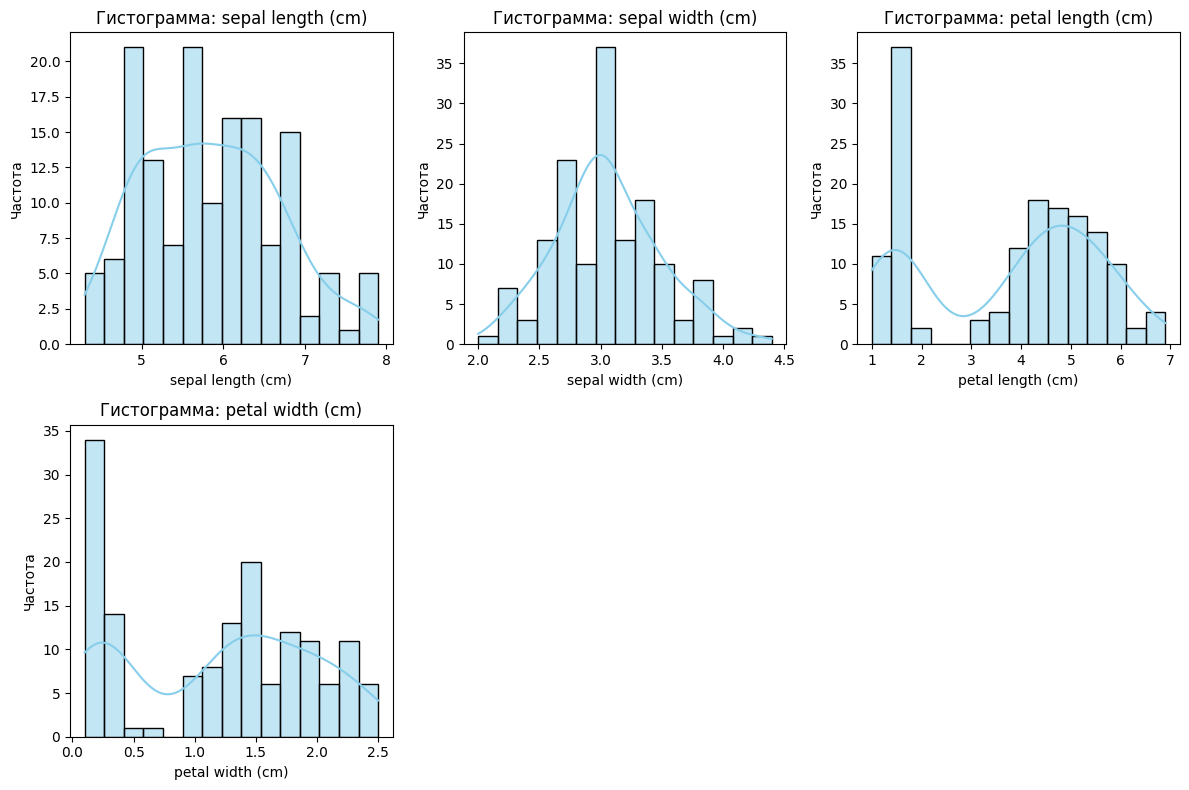

In [5]:
# 1. Визуализация основных статистик с помощью гистограмм
plt.figure(figsize=(12, 8))

# Гистограммы для всех признаков
for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[column], kde=True, color='skyblue', bins=15)
    plt.title(f'Гистограмма: {column}')
    plt.xlabel(column)
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()

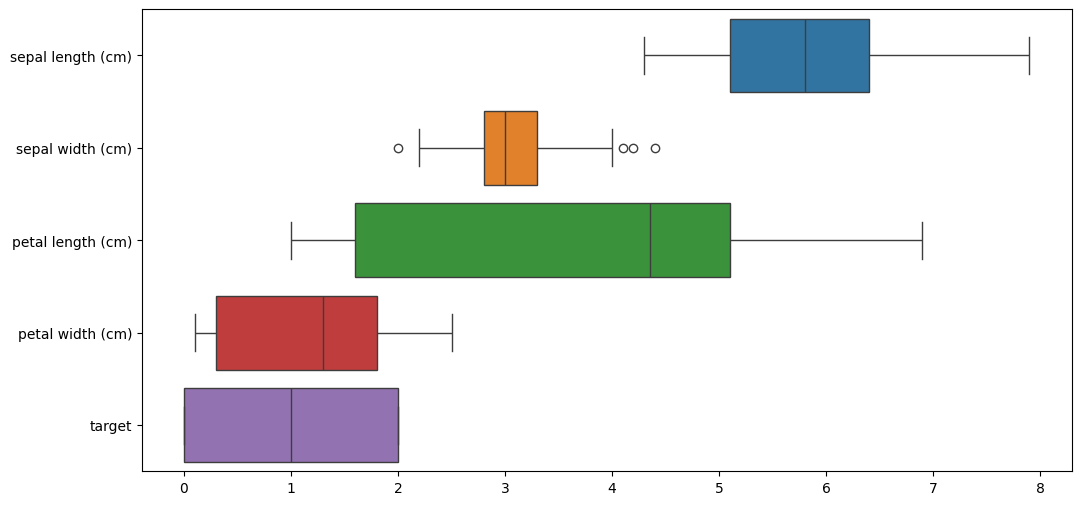

In [6]:
#### Ящики с усами (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient="h")
plt.show()

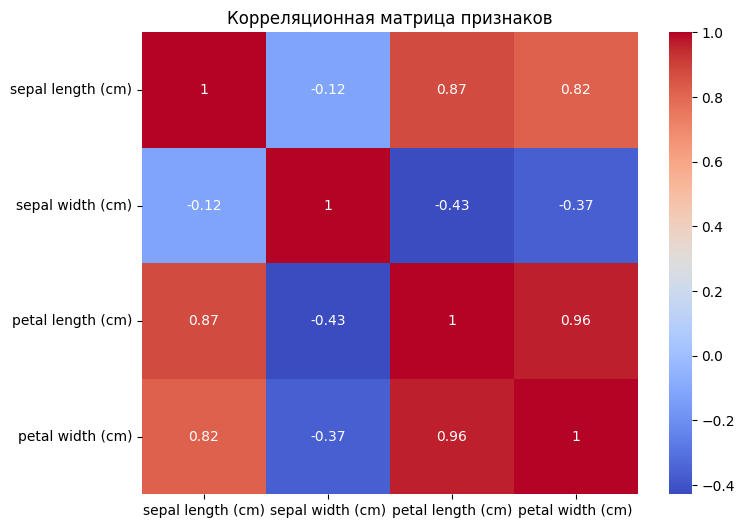

In [7]:
### 5. Корреляция признаков

# Корреляционная матрица
corr_matrix = df.iloc[:, :-1].corr()

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица признаков")
plt.show()

### Выводы:

- Все признаки различаются между классами, особенно длина и ширина лепестков.
- Наблюдается сильная корреляция между длиной и шириной лепестков.
- Датасет хорошо сбалансирован и подходит для дальнейшего анализа и построения моделей.